# AEROMMA and UFS-AQM: Read Paired Data and Create Plots

Our first example will demonstrate the basics available in MELODIES MONET to compare the UFS-AQM model results against AEROMMA aircraft observations (https://csl.noaa.gov/projects/aeromma/) for ozone, nitrogen oxide (NO), nitrogen dioxide (NO2), and carbon monoxide (CO).

This example reads in the AEROMMA and UFS-AQM paired data created by the scripts described in the Aircraft Pairing example on ReadTheDocs. This includes analysis over 3 flights and 2 days with a resampling of 30 s. To make the timeseries plot clearer, we choose to only plot 2 flights over 1 day, but you are welcome to test expanding this analysis over the entire period on your own.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`. It consists of these main parts:

* model instances

* observation instances

* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our analysis object’s attributes are set to None, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

In [4]:
control_fn='control_read_looped_aircraft_AEROMMA_UFS_AQM.yaml'
an.control=control_fn
an.read_control() 
an.control_dict  

{'analysis': {'start_time': '2023-06-27-00:00:00',
  'end_time': '2023-06-28-23:59:00',
  'output_dir': './output/aeromma_ufsaqm',
  'debug': True,
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'aeromma_ufsaqm': ['example:ufsaqm:merge_0627_L1',
      'example:ufsaqm:merge_0627_L2']}}}},
 'model': {'ufsaqm': {'files': 'example:ufsaqm:model_data',
   'mod_type': 'ufs',
   'radius_of_influence': 19500,
   'mapping': {'aeromma': {'no2_ave': 'NO2_LIF',
     'no_ave': 'NO_LIF',
     'o3_ave': 'O3_CL',
     'co': 'CO_LGR'}},
   'variables': {'pres_pa_mid': {'rename': 'pressure_model',
     'unit_scale': 1,
     'unit_scale_method': '*'},
    'temperature_k': {'rename': 'temp_model',
     'unit_scale': 1,
     'unit_scale_method': '*'}},
   'projection': None,
   'plot_kwargs': {'color': 'dodgerblue', 'marker': '^', 'linestyle': ':'}}},
 'obs': {'aeromma': {'filename': 'example:ufsaqm:AEROMMA',
   'obs_type': 'aircraft',
   'time_var': 'Time_Start',
   'resample': '30s',
   'vari

Now, some of our analysis object’s attributes are populated:

In [5]:
an

analysis(
    control='control_read_looped_aircraft_AEROMMA_UFS_AQM.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2023-06-27 00:00:00'),
    end_time=Timestamp('2023-06-28 23:59:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/aeromma_ufsaqm',
    output_dir_save='./output/aeromma_ufsaqm',
    output_dir_read='./output/aeromma_ufsaqm',
    debug=True,
    save=None,
    read={'paired': {'method': 'netcdf', 'filenames': {'aeromma_ufsaqm': ['example:ufsaqm:merge_0627_L1', 'example:ufsaqm:merge_0627_L2']}}},
    regrid=False,
)

## Load the model data

The driver will automatically loop through the “models” found in the model section of the YAML file and create an instance of melodies_monet.driver.model for each that includes the

* label

* mapping information

* file names (can be expressed using a glob expression)

* xarray object

In [6]:
an.open_models()

ufs
example:ufsaqm:model_data
**** Reading UFS-AQM model output...


Applying open_models() populates the models attribute.

In [7]:
an.models

{'ufsaqm': model(
     model='ufs',
     is_global=False,
     radius_of_influence=19500,
     mod_kwargs={'var_list': ['co', 'o3_ave', 'no_ave', 'no2_ave', 'lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufsaqm:model_data',
     label='ufsaqm',
     obj=...,
     extra_calc=None,
     mapping={'aeromma': {'no2_ave': 'NO2_LIF', 'no_ave': 'NO_LIF', 'o3_ave': 'O3_CL', 'co': 'CO_LGR'}},
     variable_dict={'temp_model': {'rename': 'temp_model', 'unit_scale': 1, 'unit_scale_method': '*'}, 'pressure_model': {'rename': 'pressure_model', 'unit_scale': 1, 'unit_scale_method': '*'}},
     label='ufsaqm',
     ...
 )}

We can access the underlying dataset with the obj attribute.

In [8]:
an.models['ufsaqm'].obj

<xarray.Dataset> Size: 880MB
Dimensions:         (time: 1, z: 64, y: 488, x: 775)
Coordinates:
    latitude        (y, x) float64 3MB dask.array<chunksize=(488, 775), meta=np.ndarray>
    longitude       (y, x) float64 3MB dask.array<chunksize=(488, 775), meta=np.ndarray>
  * time            (time) datetime64[ns] 8B 2023-06-27T13:00:00
Dimensions without coordinates: z, y, x
Data variables:
    co              (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    o3_ave          (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    no_ave          (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    no2_ave         (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    temp_model      (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    surfpres_pa     (time, y, x) float32 2MB dask.array<chunksize=(1, 488, 775), meta=np.ndarray>
    dp_pa           (time, z, y, x) float32 97MB dask.array<chunksize=(1, 64, 488, 775), meta=np.ndarray>
    surfalt_m       (time, y, x) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    dz_m            (time, z, y, x) float32 97MB 47.32 47.32 ... 8.865e+03
    pressure_model  (time, z, y, x) float32 97MB 1.008e+05 1.008e+05 ... 37.92
    alt_msl_m_full  (time, z, y, x) float32 97MB -47.32 -47.32 ... -6.142e+04
Attributes: (12/15)
    ak:           [2.0000000e+01 6.4247002e+01 1.3778999e+02 2.2195799e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    cen_lat:      50.0
    cen_lon:      -118.0
    dlat:         0.11690814
    dlon:         0.11690814
    ...           ...
    lat1:         -28.5
    lat2:         28.5
    lon1:         -45.25
    lon2:         45.25
    ncnsto:       202
    source:       FV3GFS

## Load the observational data

As with the model data, the driver will loop through the “observations” found in the obs section of the YAML file and create an instance of melodies_monet.driver.observation for each.

In [9]:
an.open_obs()

In [10]:
an.obs

{'aeromma': observation(
     obs='aeromma',
     label='aeromma',
     file='example:ufsaqm:AEROMMA',
     obj=...,
     extra_calc=None,
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'O3_CL': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'O3 (ppbv)'}, 'NO_LIF': {'unit_scale': 1000.0, 'unit_scale_method': '/', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'NO (ppbv)'}, 'NO2_LIF': {'unit_scale': 1000.0, 'unit_scale_method': '/', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'NO2 (ppbv)'}, 'CO_LGR': {'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'CO (ppbv)'}, 'Time_Start': {'rename': 'time'}, 'pressure_obs': {'rename': 'pressure_obs', 'unit_scale': 100, 'unit_scale_method': '*'}, 'temp_obs': {'rename': 'temp_obs', 'unit_scale': 1, 'unit_scale_method': '*'}, 'latitude': {'rename': 'la

In [11]:
an.obs['aeromma'].obj

<xarray.Dataset> Size: 14kB
Dimensions:       (time: 173)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2023-06-27T16:09:00 ... 2023-06-2...
Data variables:
    CO_LGR        (time) float64 1kB 143.8 143.0 138.4 ... 141.8 140.9 140.4
    pressure_obs  (time) float64 1kB 9.025e+04 8.86e+04 ... 9.171e+04 9.246e+04
    temp_obs      (time) float64 1kB 293.5 292.1 290.8 ... 295.6 297.4 298.0
    latitude      (time) float64 1kB 34.63 34.63 34.65 ... 34.6 34.61 34.62
    longitude     (time) float64 1kB -118.1 -118.1 -118.2 ... -118.1 -118.1
    altitude      (time) float64 1kB 982.2 1.143e+03 1.303e+03 ... 857.9 799.8
    NO_LIF        (time) float64 1kB 0.2573 0.3002 0.2095 ... 0.2122 0.1891
    NO2_LIF       (time) float64 1kB nan nan nan nan ... 0.876 0.6945 0.5946
    O3_CL         (time) float64 1kB 56.09 56.16 57.02 ... 62.91 63.3 63.07

## Read in the Paired Output Netcdf File

We read in the AEROMMA and UFS-AQM paired data created by the scripts here on Hera (/scratch1/BMC/rcm2/rhs/monet_example/AEROMMA/submit_jobs). This includes analysis over 4 flights and 2 days with a resampling of 30 s.

In [12]:
an.read_analysis()

Reading: /home/rschwantes/.cache/pooch/552c088223ee8b2eb75d007d06daec11-0627_L1_aeromma_ufsaqm.nc4
Reading: /home/rschwantes/.cache/pooch/e181e3c31f7bc812358c193679440ed5-0627_L2_aeromma_ufsaqm.nc4


In [13]:
an.paired

{'aeromma_ufsaqm': pair(
     type='aircraft',
     radius_of_influence=None,
     obs='aeromma',
     model='ufsaqm',
     model_vars=['no2_ave', 'no_ave', 'o3_ave', 'co'],
     obs_vars=['NO2_LIF', 'NO_LIF', 'O3_CL', 'CO_LGR'],
     filename='aeromma_ufsaqm.nc',
 )}

## Plot

The plotting() routine produces plots.

Using vertprofile_bins from YAML range: {'start': 0, 'stop': 4000, 'step': 500}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 4000, 'step': 500}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 4000, 'step': 500}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 4000, 'step': 500}
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

aeromma vs. ufsaqm: Custom statistical test, P_val:5.931e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

aeromma vs. ufsaqm: Custom statistical test, P_val:5.425e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ***

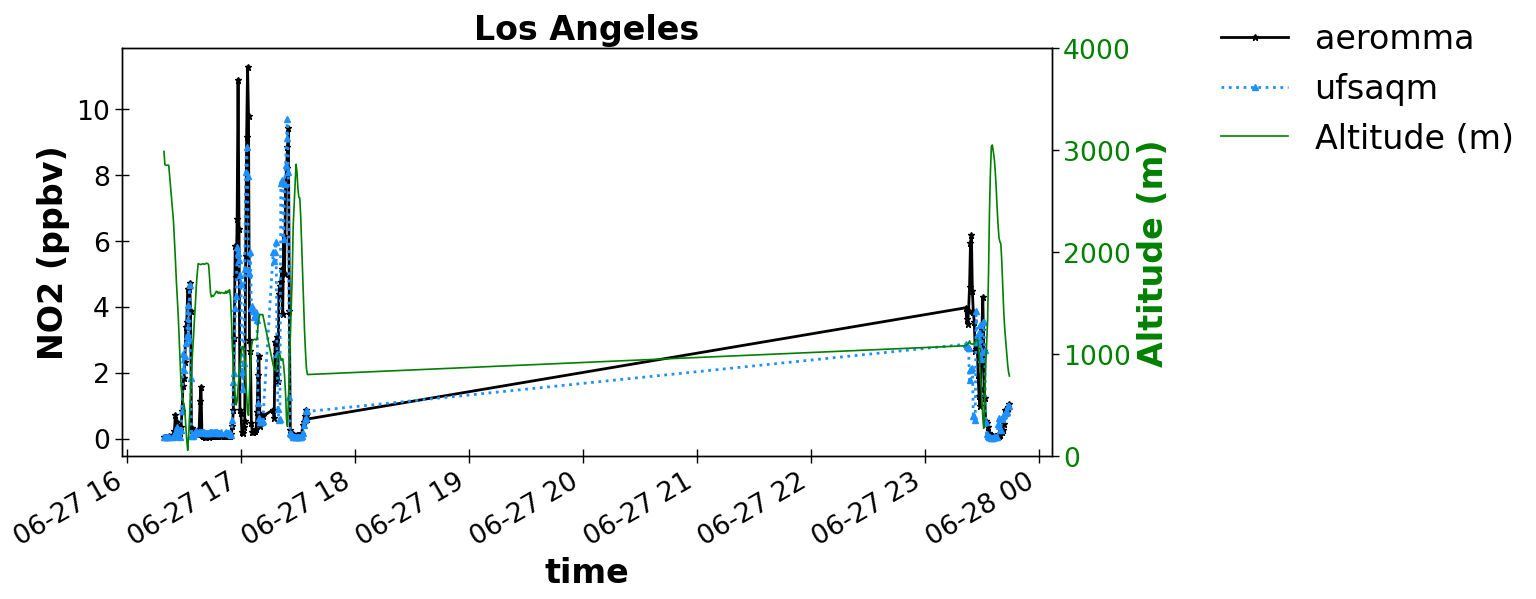

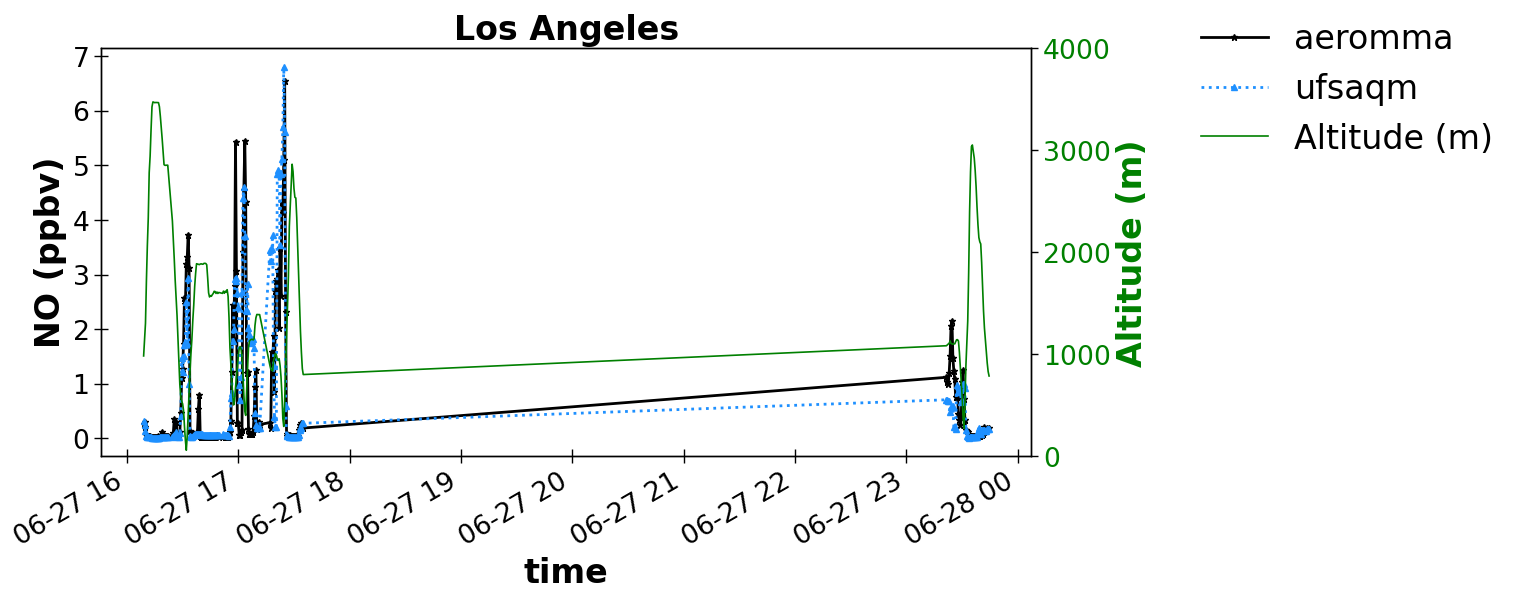

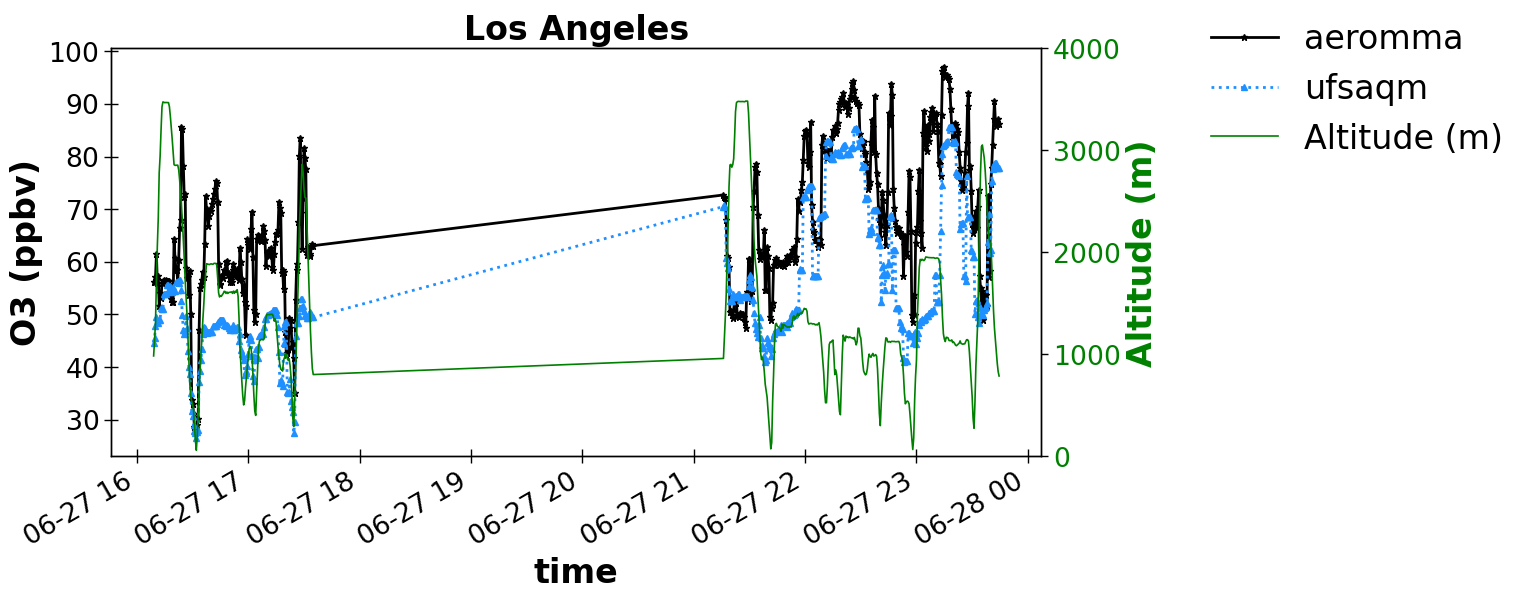

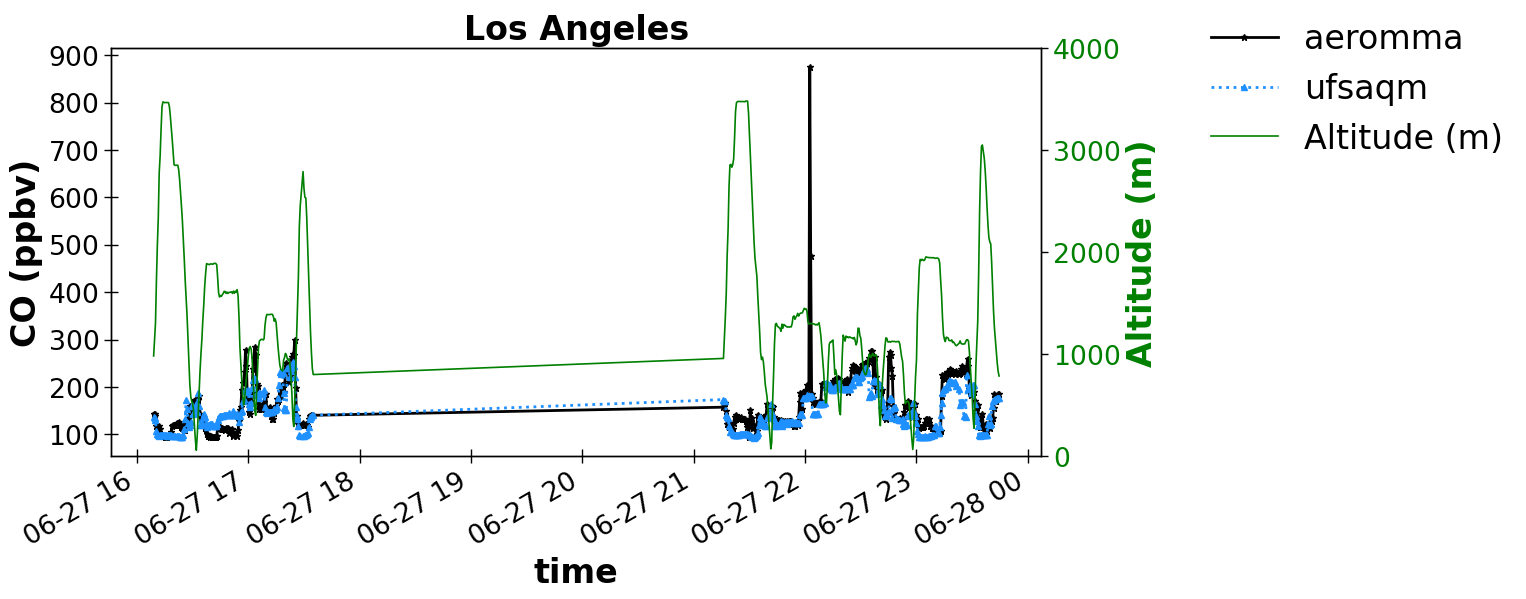

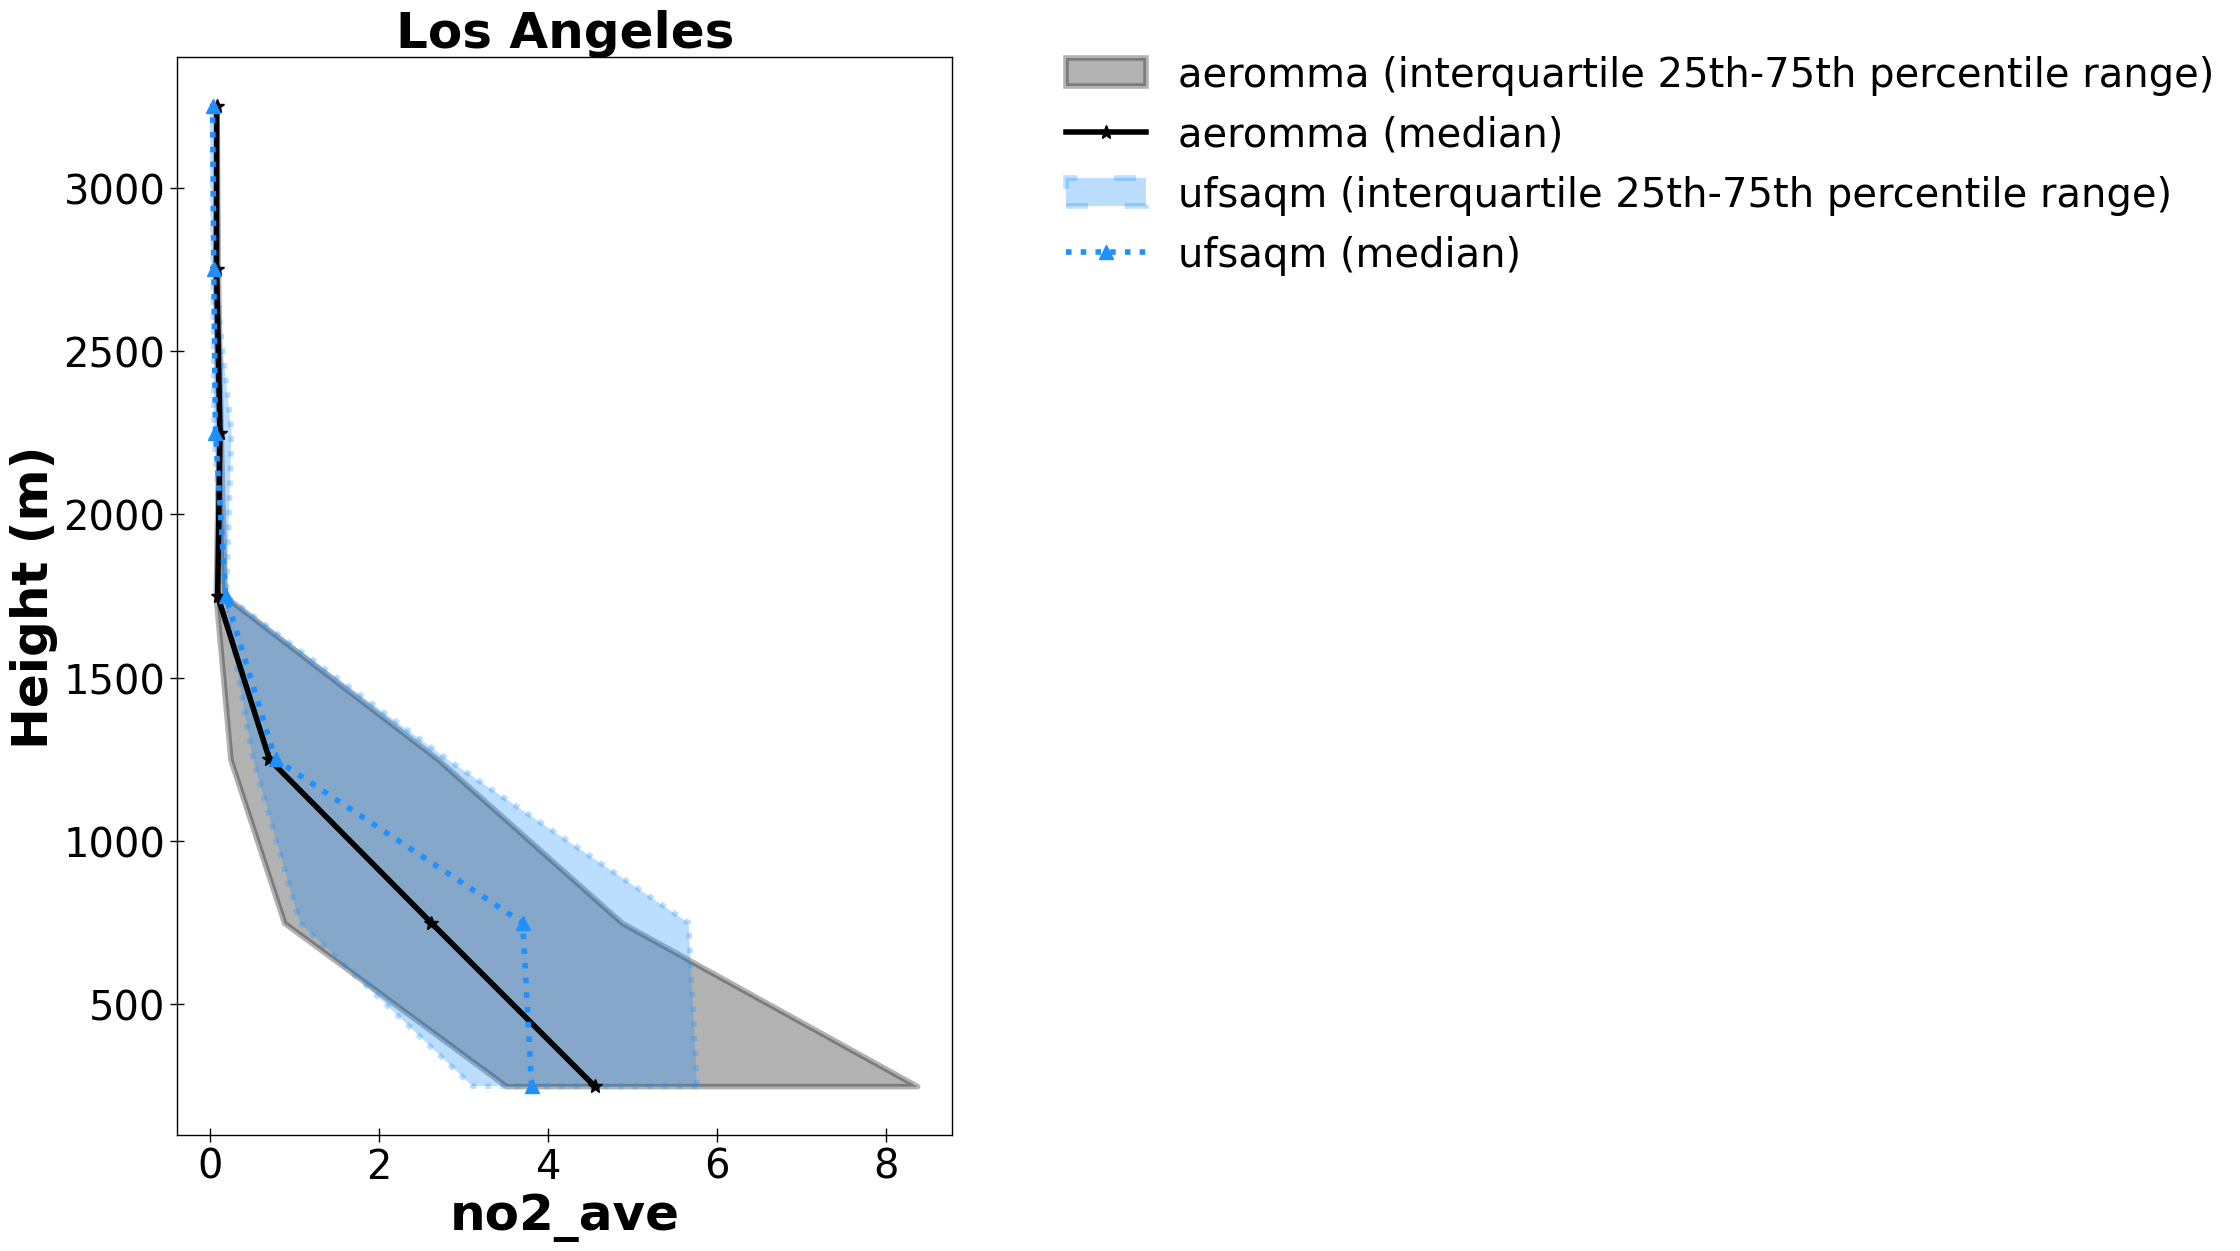

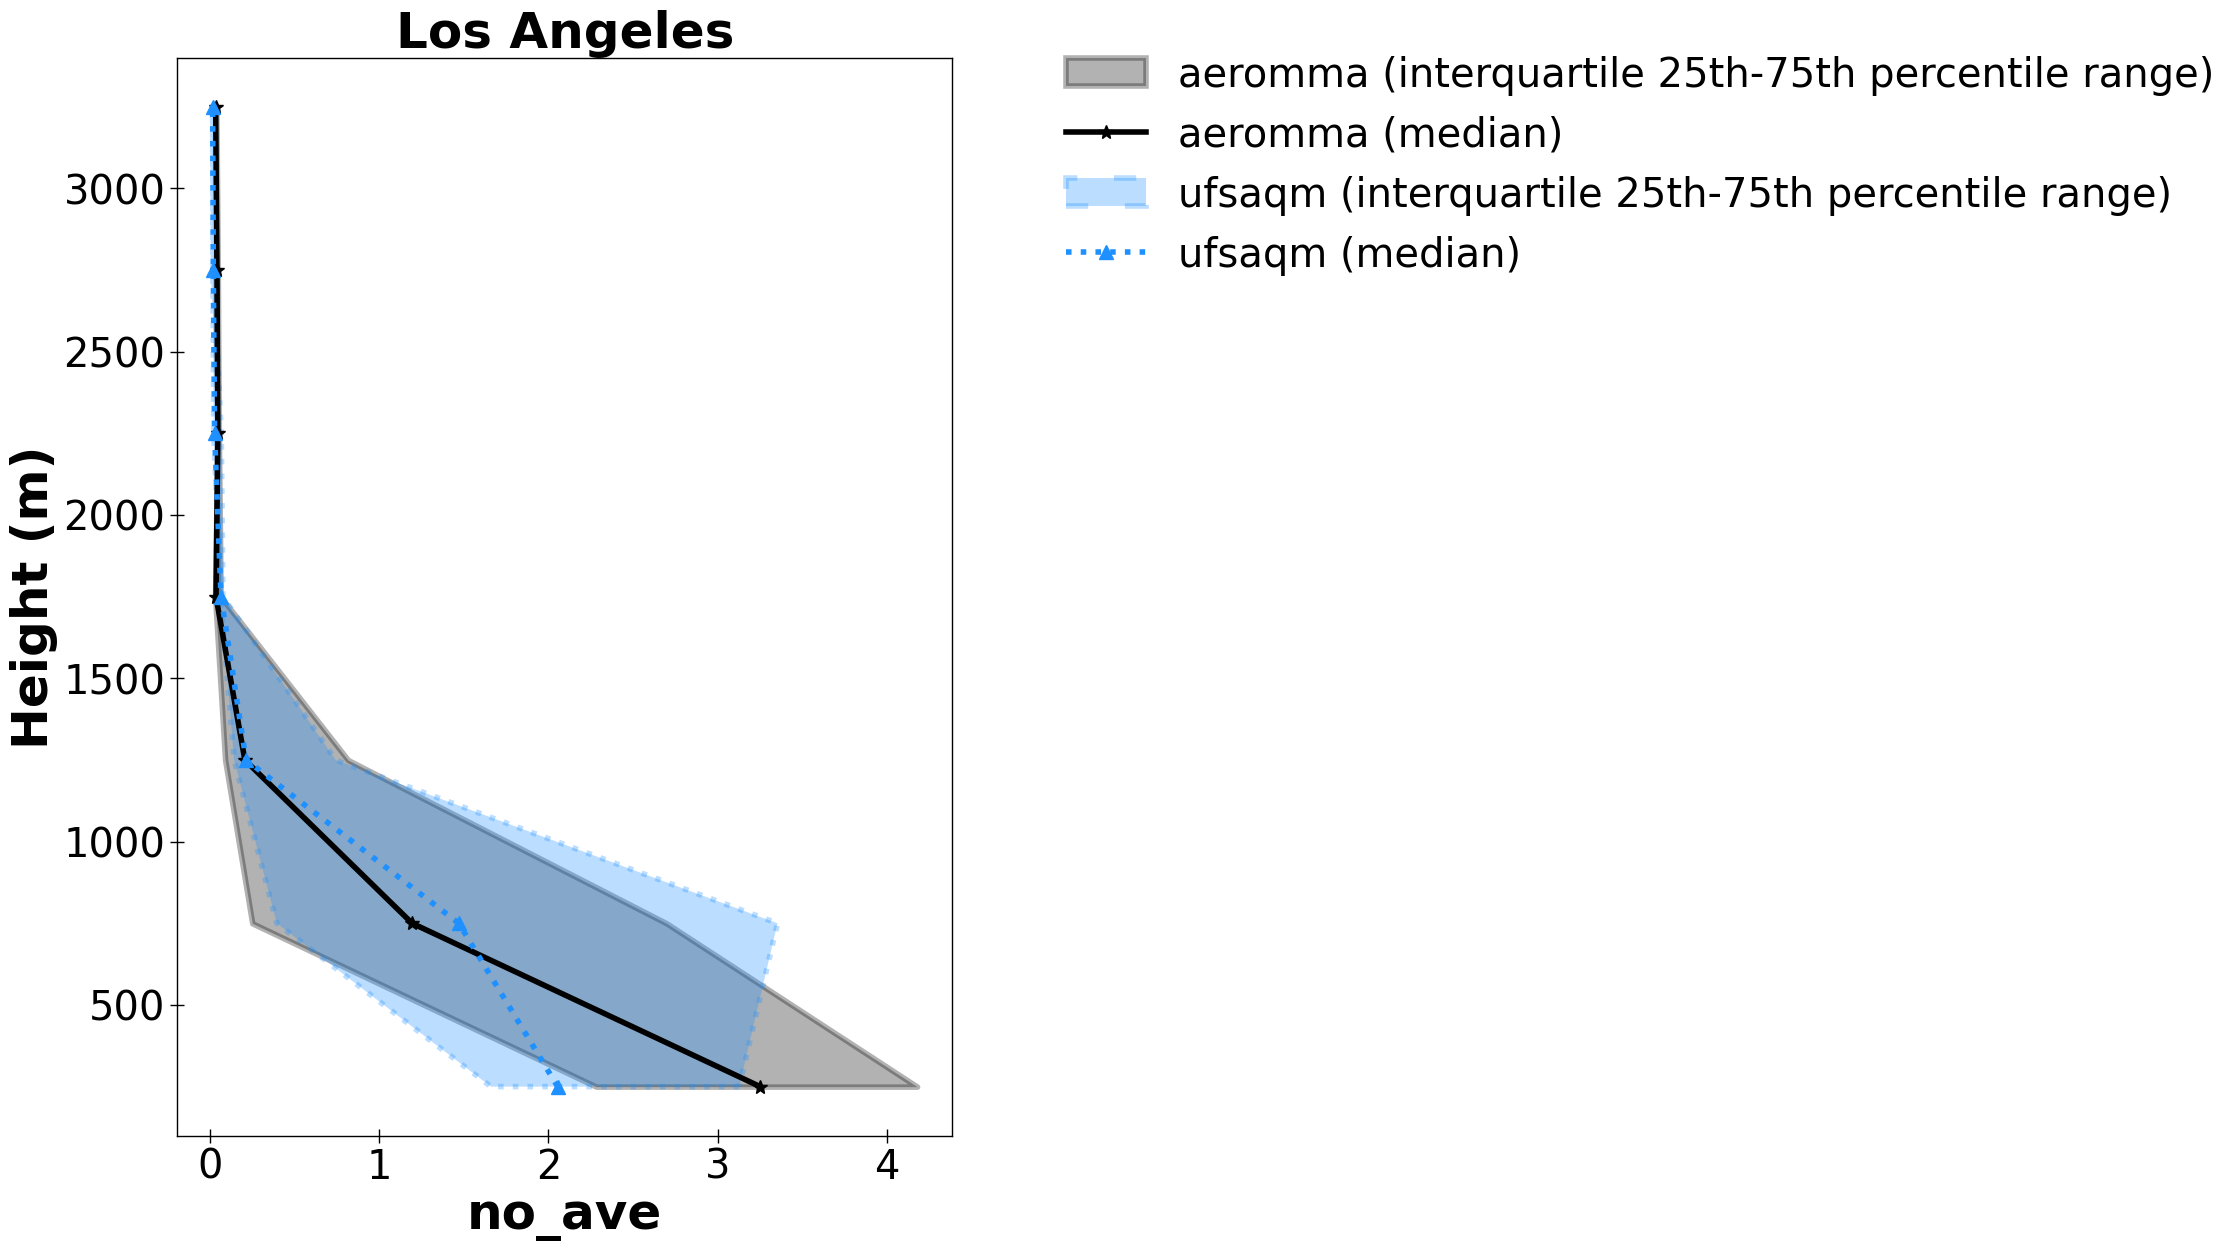

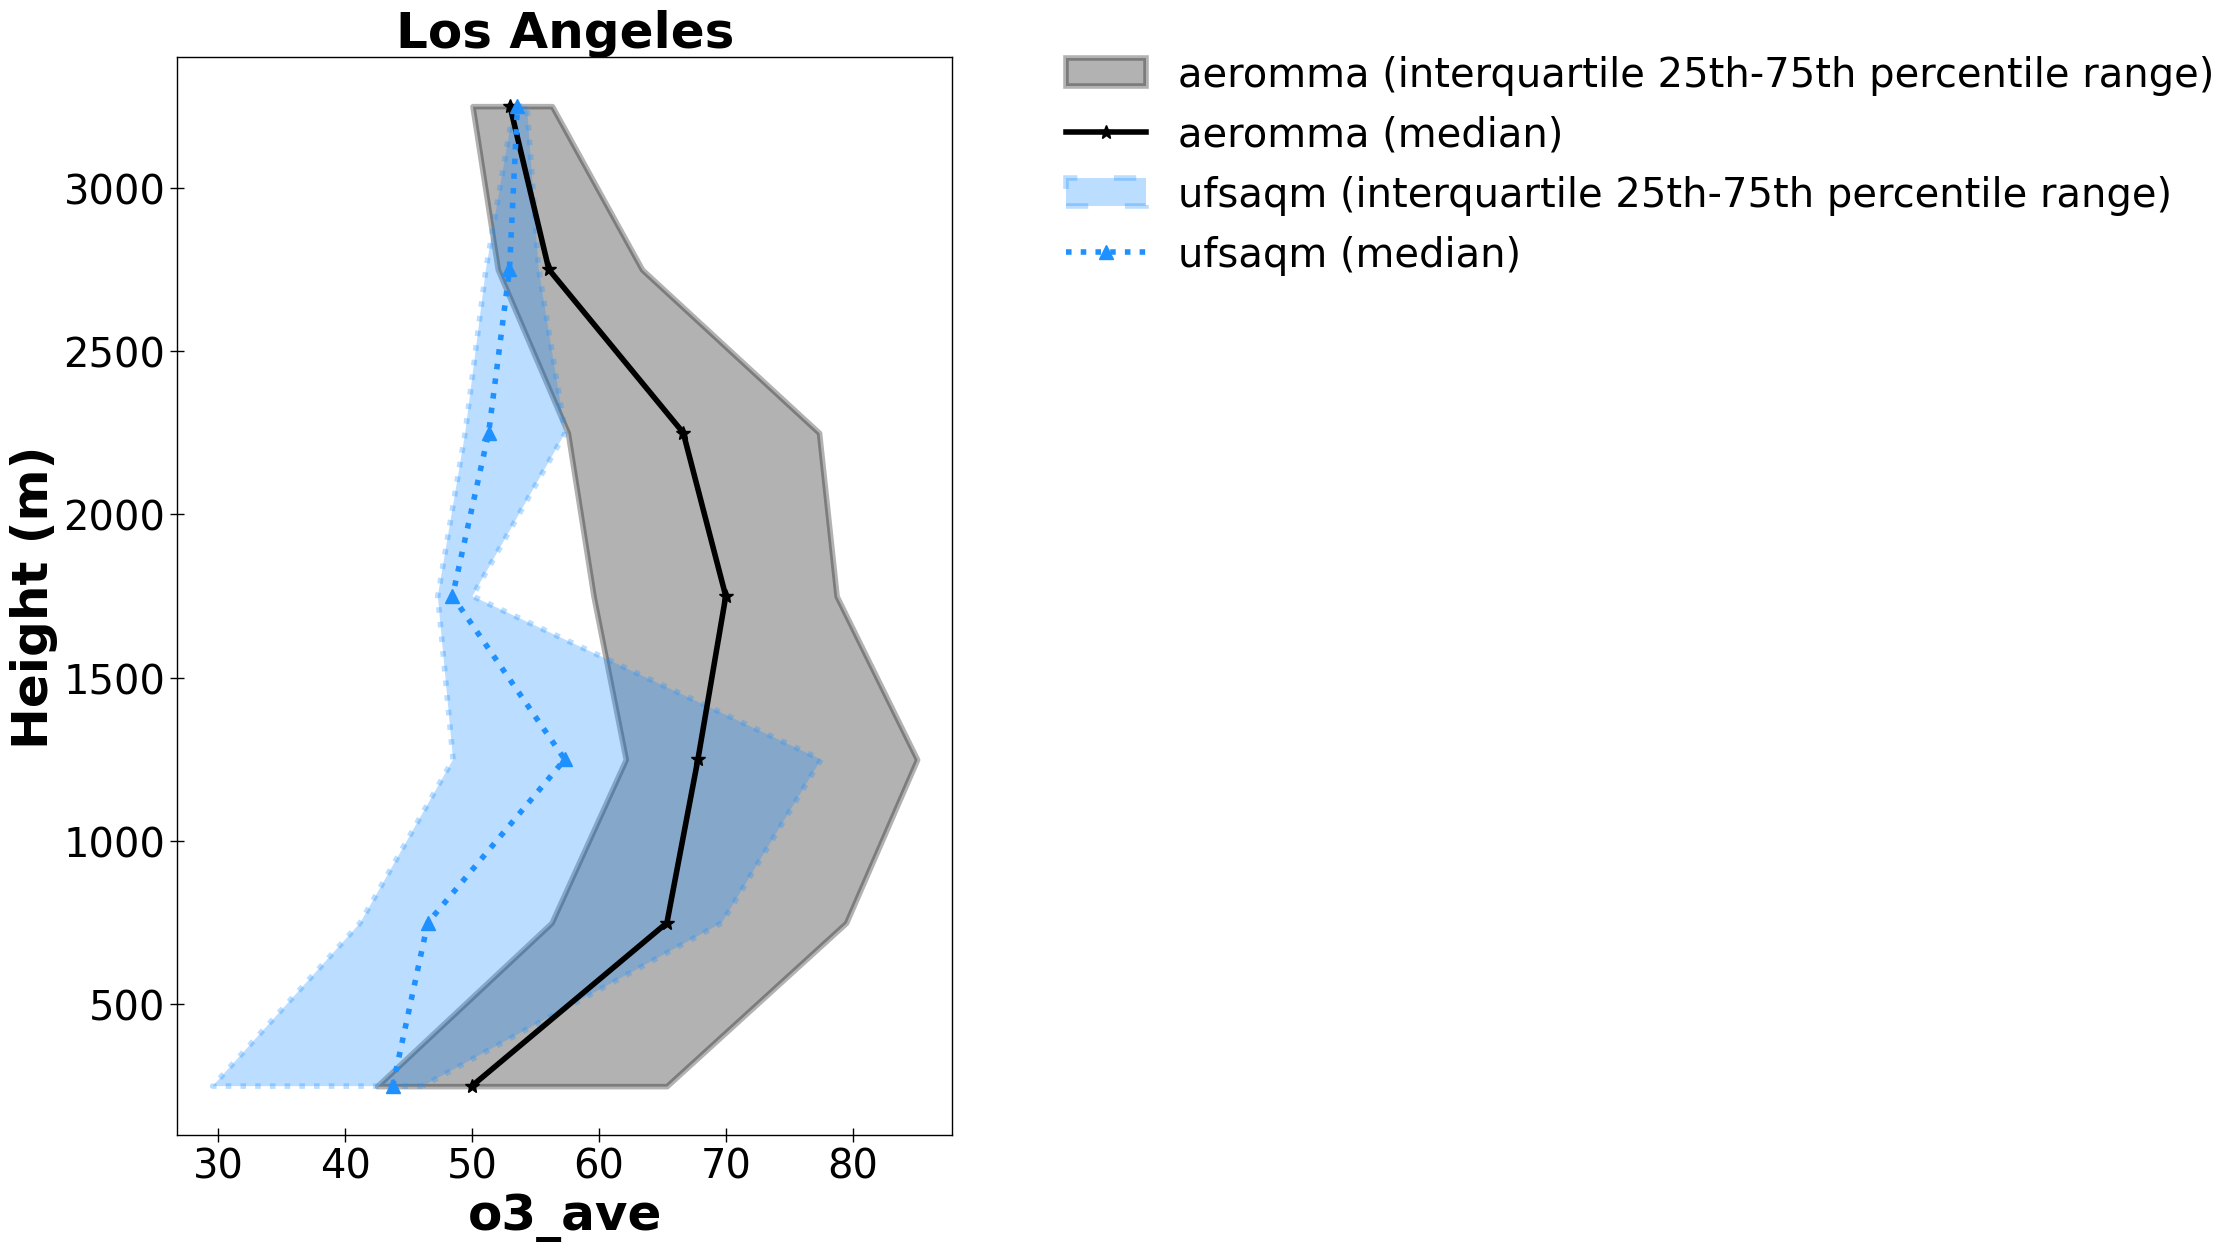

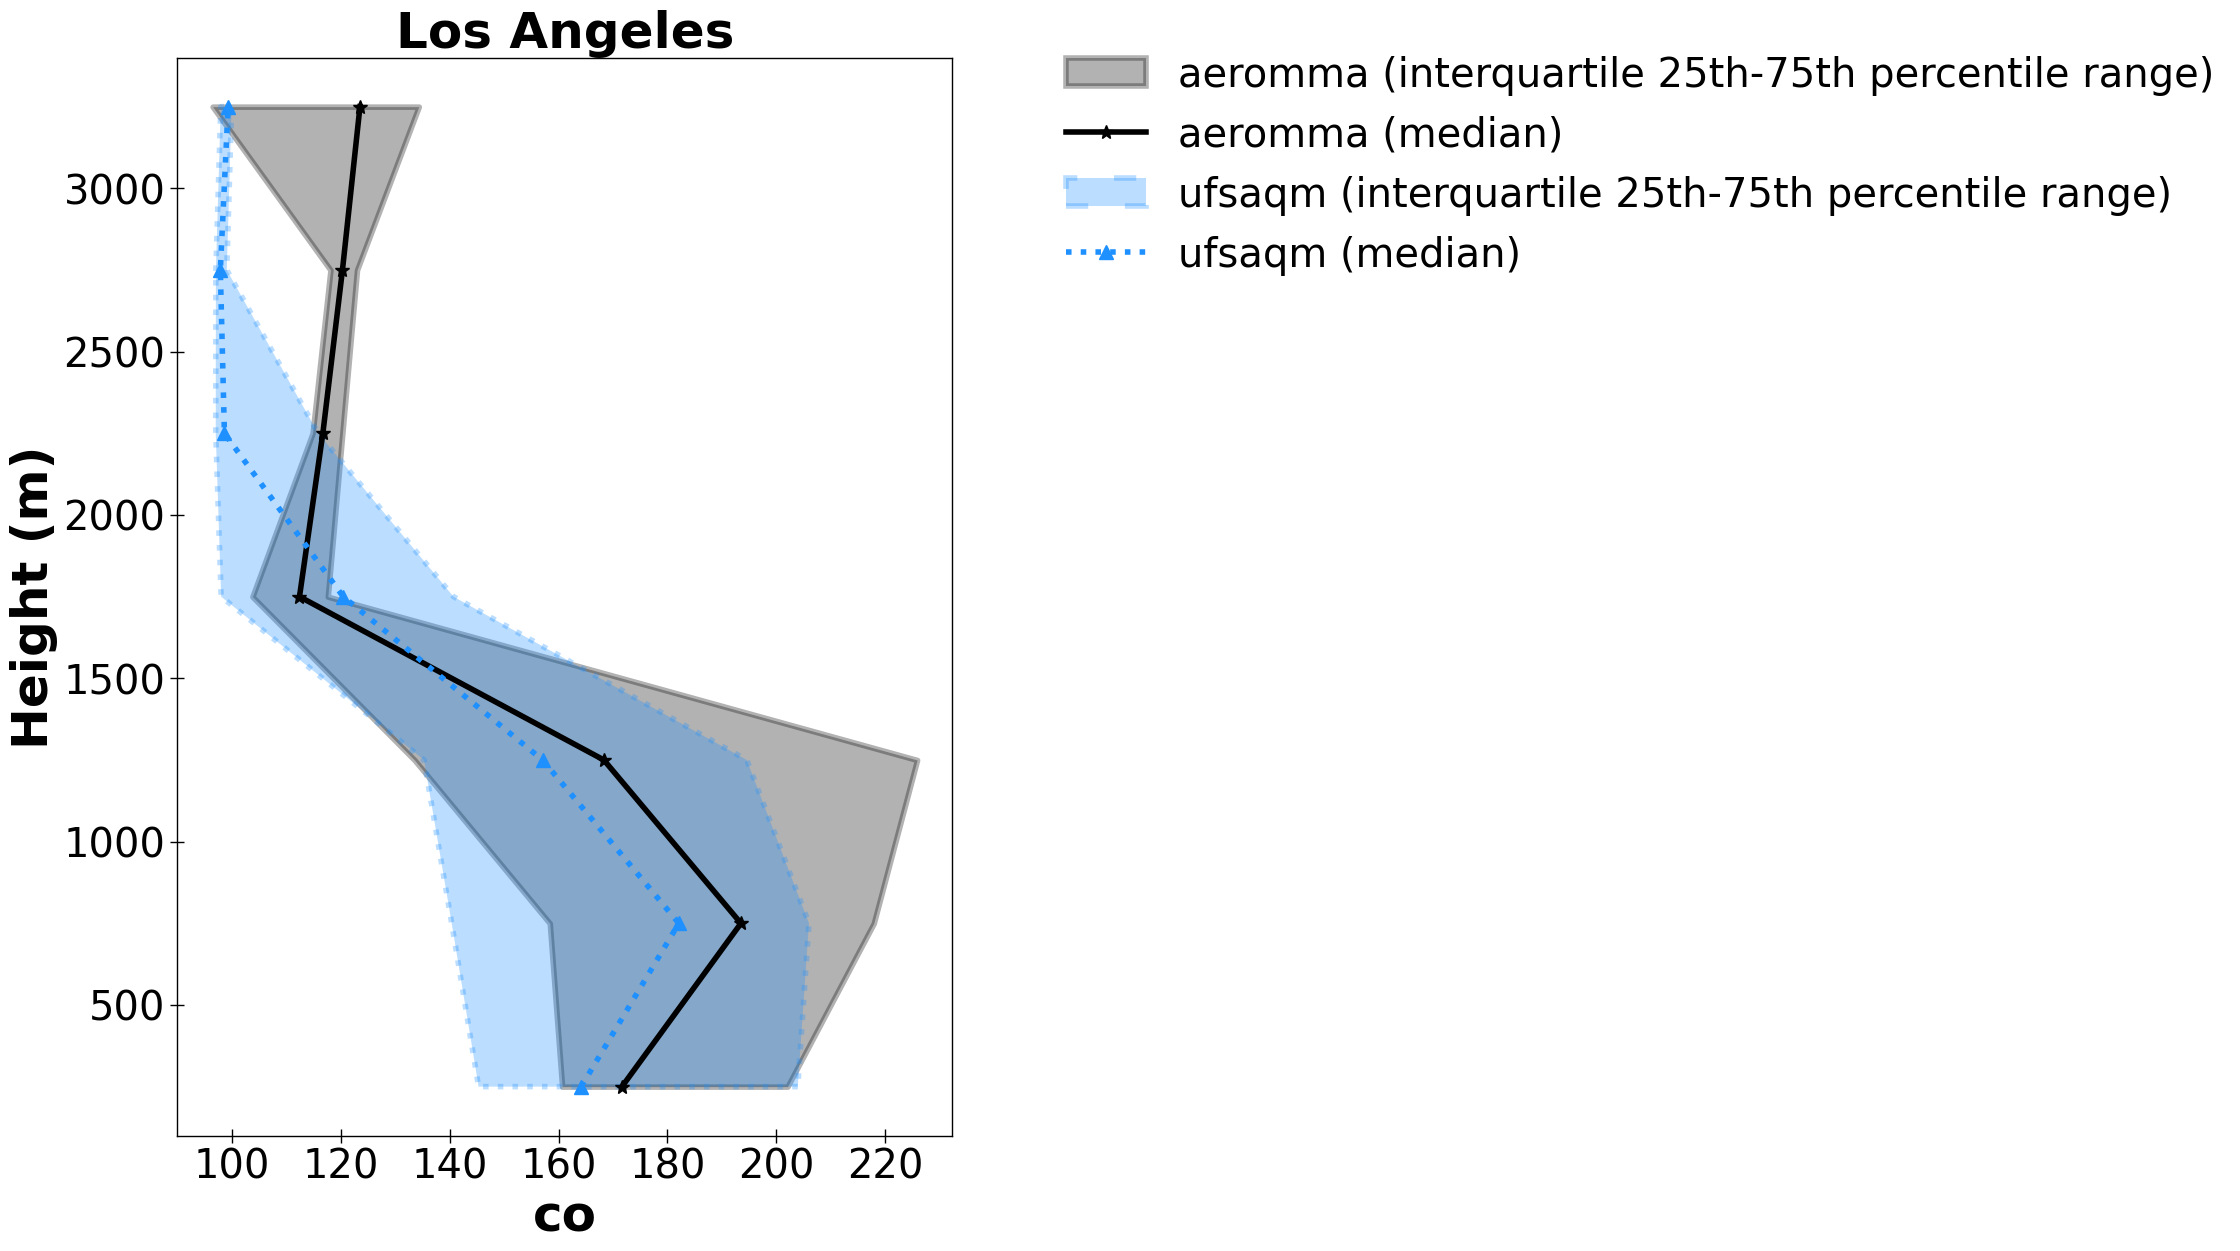

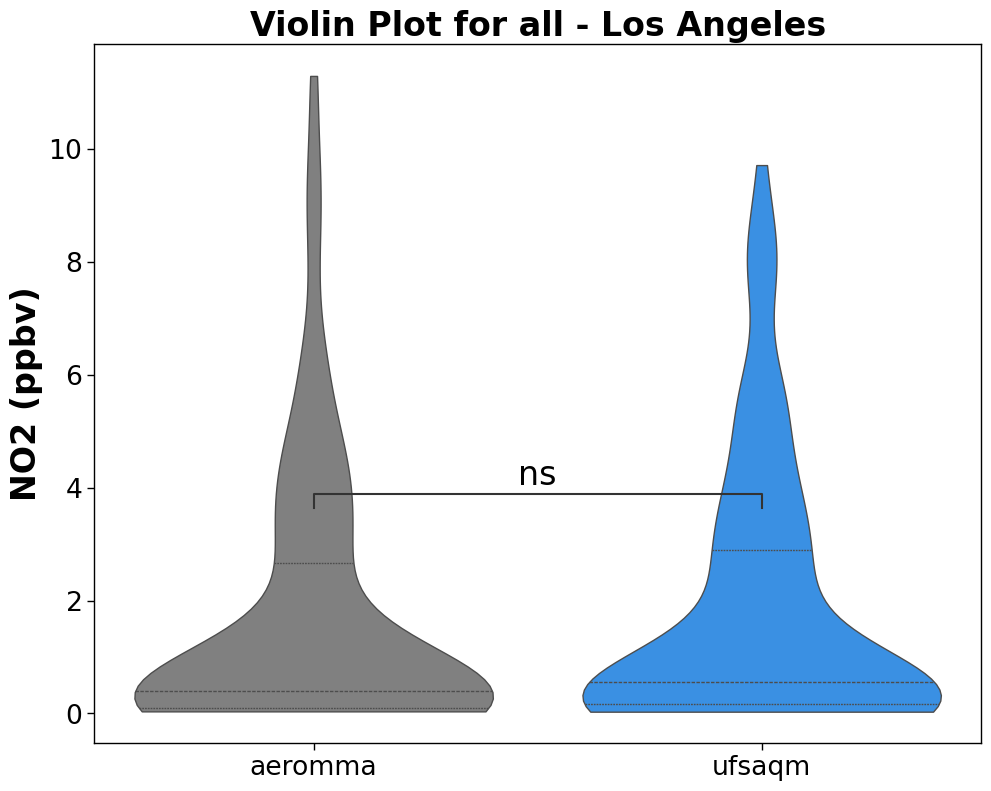

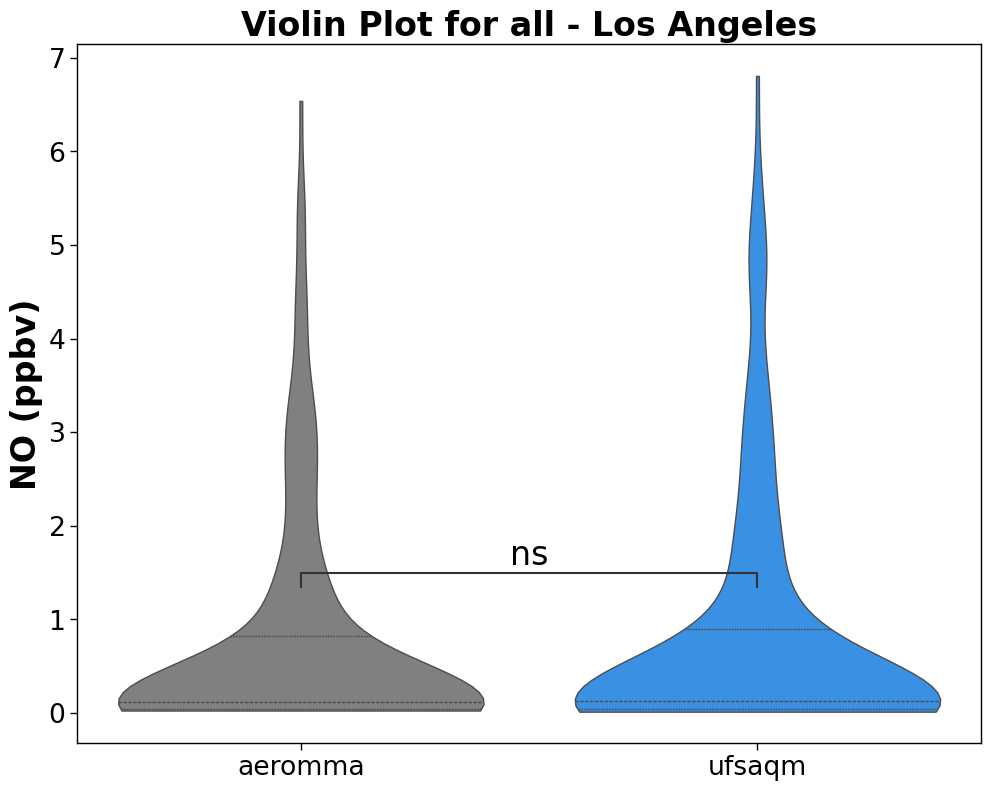

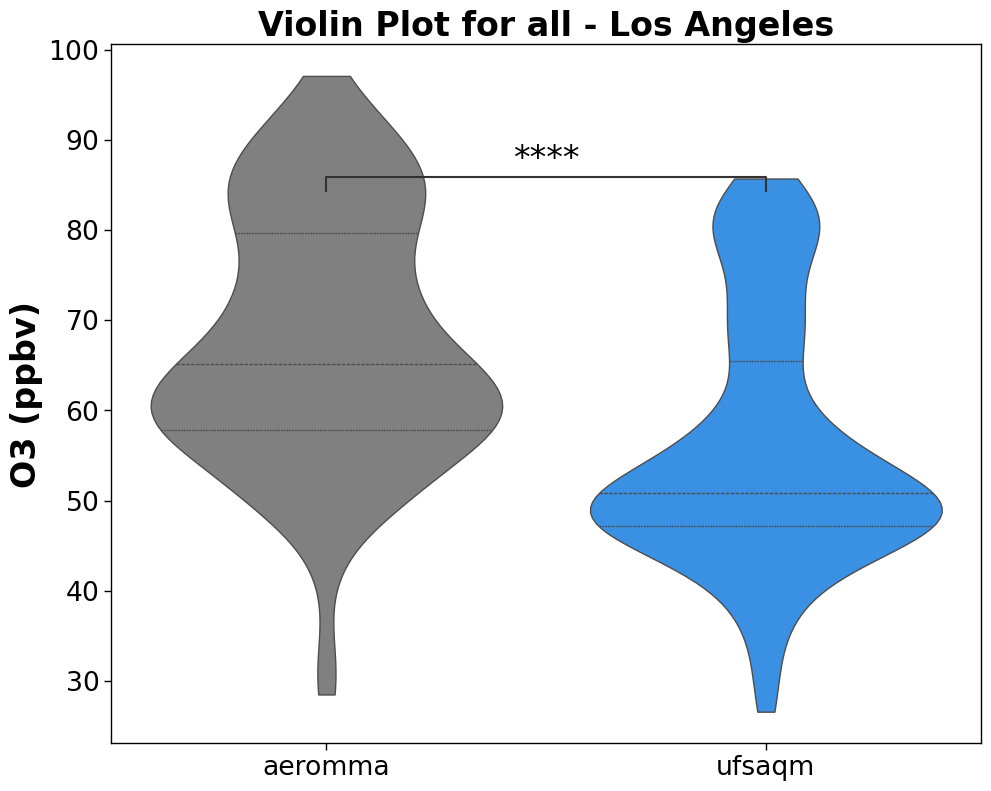

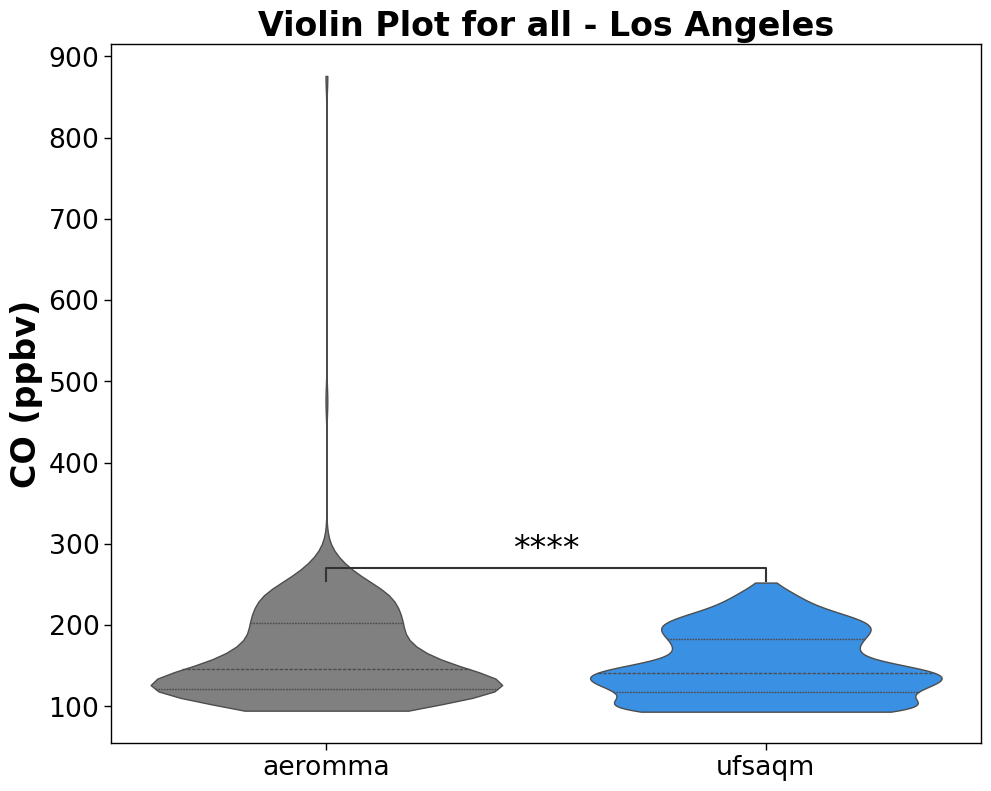

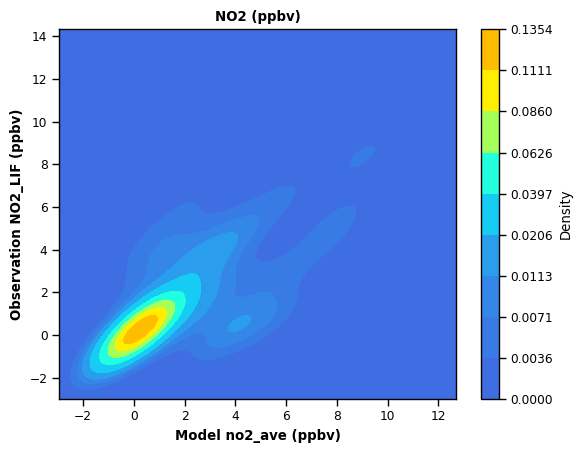

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.NO_LIF.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...
Processing scatter density plot for model 'ufsaqm' and observation 'aeromma'...
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.NO_LIF.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...


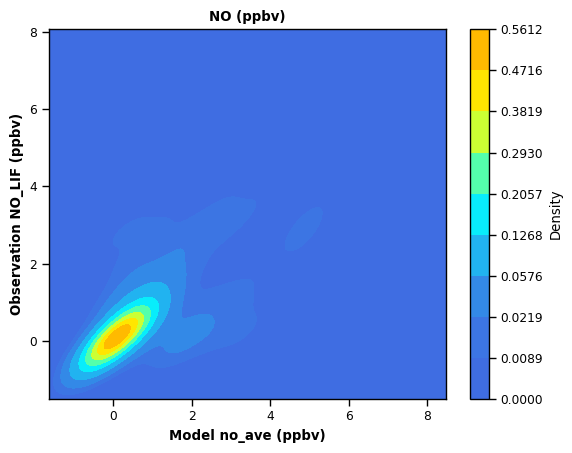

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.O3_CL.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...
Processing scatter density plot for model 'ufsaqm' and observation 'aeromma'...
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.O3_CL.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...


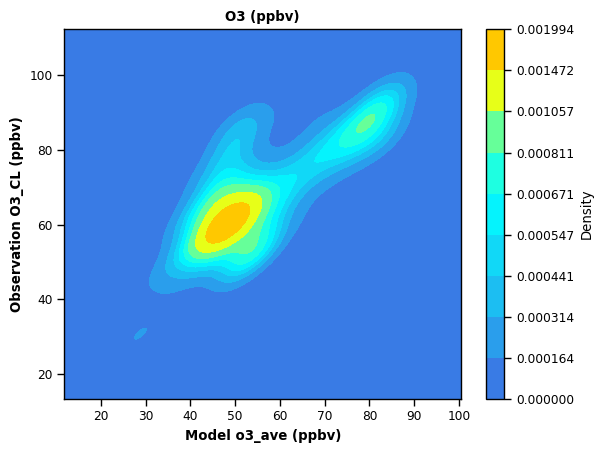

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.CO_LGR.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...
Processing scatter density plot for model 'ufsaqm' and observation 'aeromma'...
Saving scatter density plot to ./output/aeromma_ufsaqm/plot_grp4.scatter_density.CO_LGR.2023-06-27_00.2023-06-28_23.all.Los Angeles_aeromma_vs_ufsaqm.png...


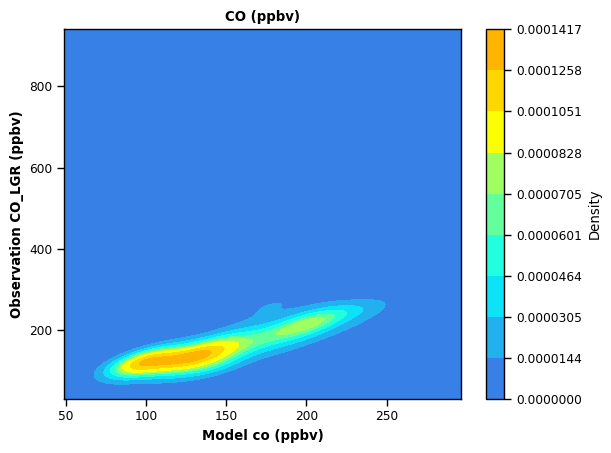

Reference std: 2.40389034741695
Reference std: 1.234721238249615
Reference std: 14.047438930884008
Reference std: 60.249468305001415
[0.5930577967017696]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

aeromma vs. ufsaqm: Custom statistical test, P_val:5.931e-01
[0.5425320289189932]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

aeromma vs. ufsaqm: Custom statistical test, P_val:5.425e-01
[6.04031001966165e-36]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

aeromma vs. ufsaqm: Custom statistical test, P_val:6.040e-36
[5.963905975706521e-05]
p-value annotation 

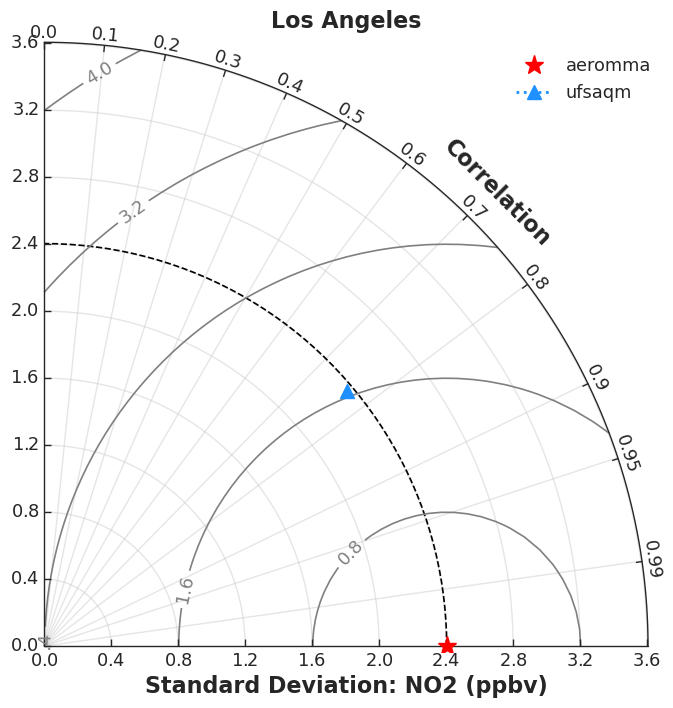

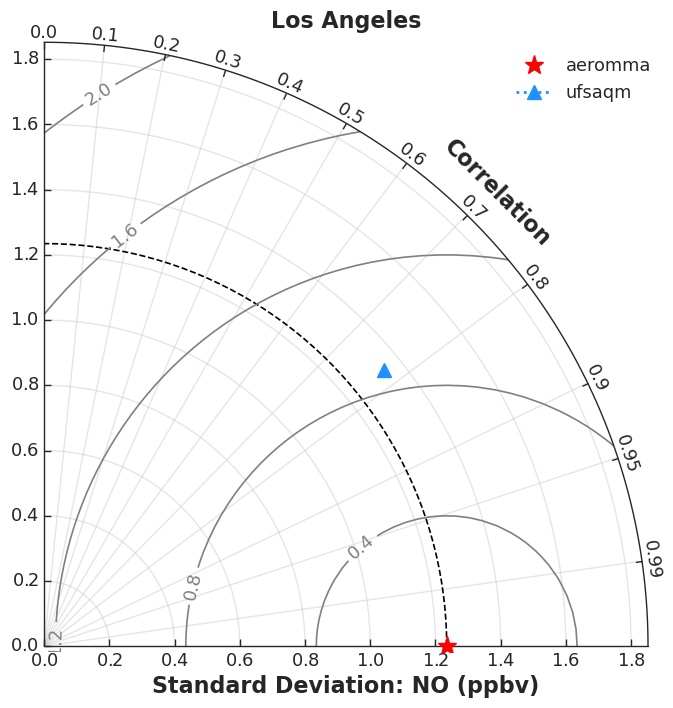

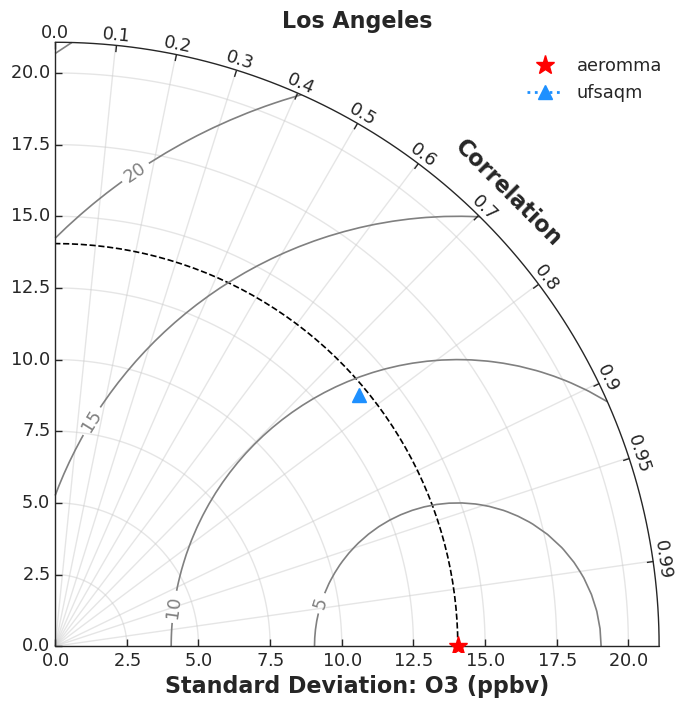

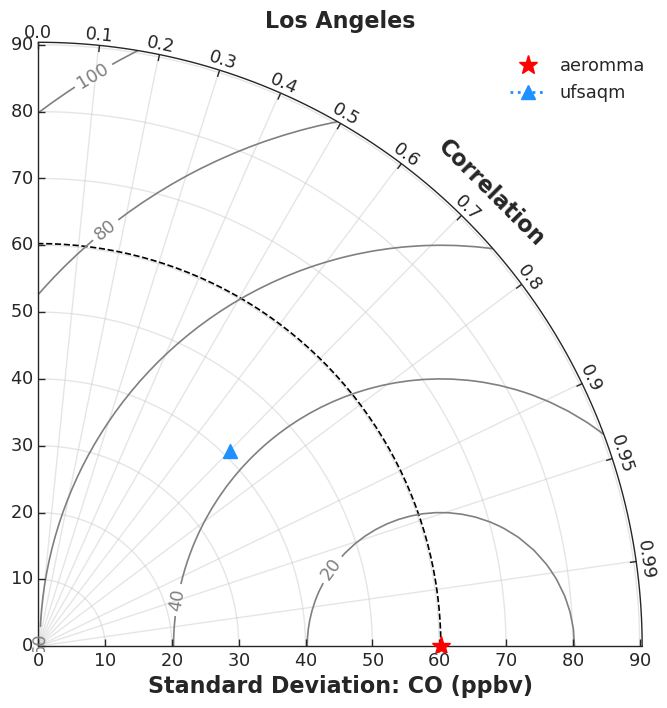

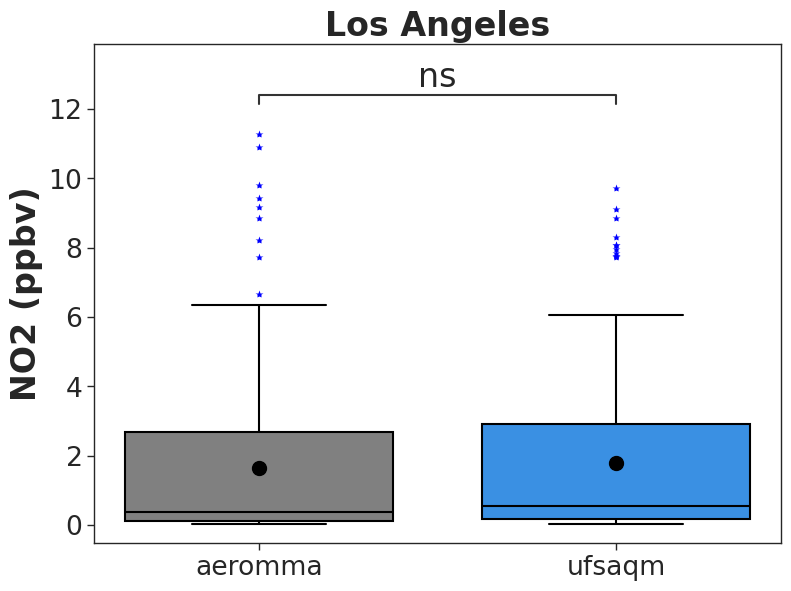

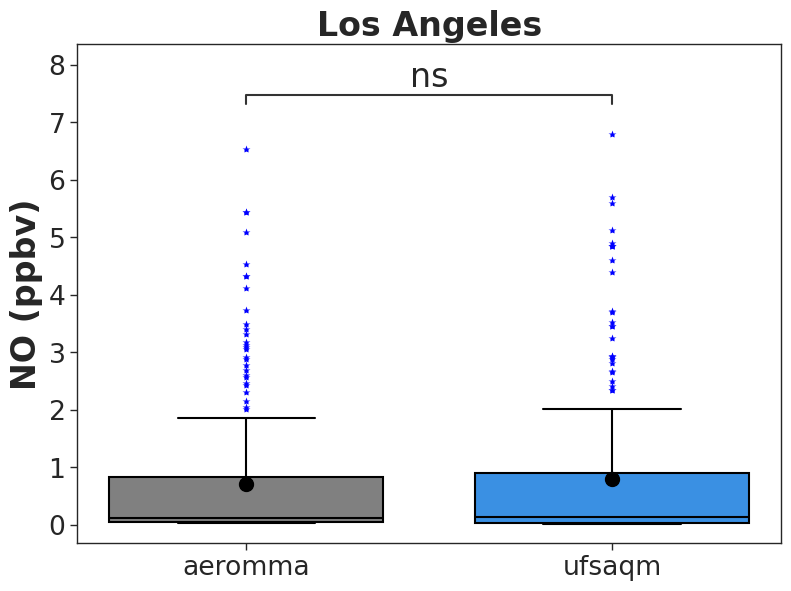

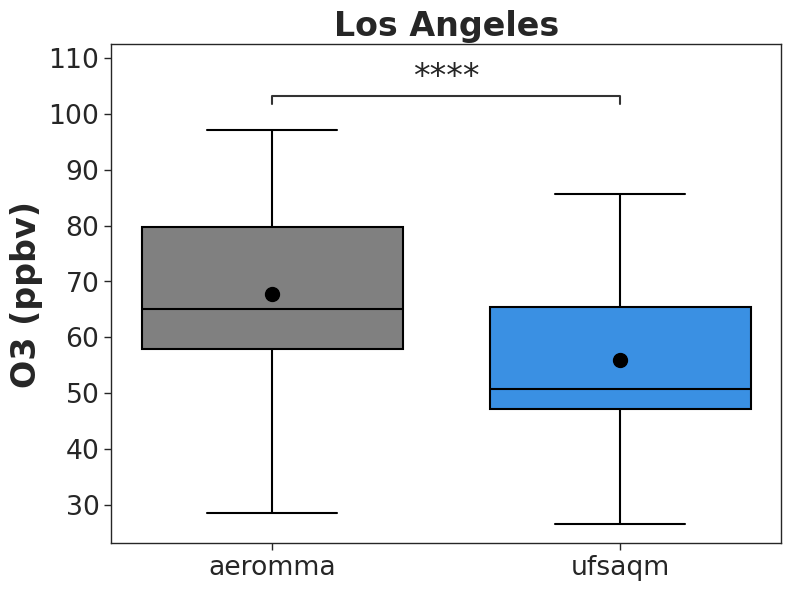

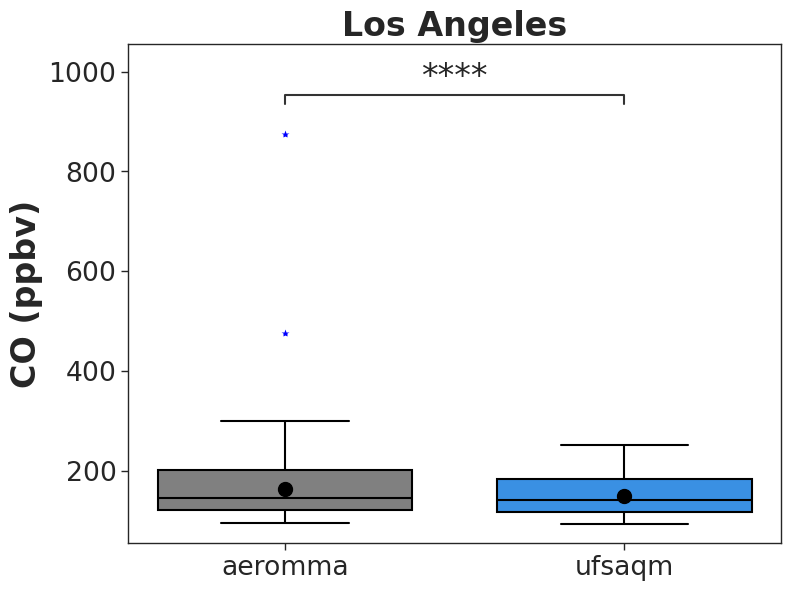

In [14]:
#And this generates all the plots.
an.plotting()